In [1]:
import os
import shutil
from google.colab import drive

# --- 1. Mount Drive ---
if not os.path.exists('/content/drive/MyDrive'):
    drive.mount('/content/drive')

# --- 2. Paths ---
PROJECT_DRIVE = '/content/drive/MyDrive/PlantDiseaseProject'
LOCAL_DATA = '/content/data'

# unzip locally
need_unzip = not (
    os.path.exists(os.path.join(LOCAL_DATA, 'PlantVillage')) and
    len(os.listdir(os.path.join(LOCAL_DATA, 'PlantVillage'))) > 30
)

if need_unzip:
    print("Re-unzipping data to local SSD...")
    for f in ['PlantVillage', 'PlantDoc']:
        path = os.path.join(LOCAL_DATA, f)
        if os.path.exists(path):
            shutil.rmtree(path)
    os.makedirs(os.path.join(LOCAL_DATA, 'PlantVillage'), exist_ok=True)
    os.makedirs(os.path.join(LOCAL_DATA, 'PlantDoc'), exist_ok=True)

    !unzip -q "$PROJECT_DRIVE/plantvillage-dataset.zip" -d "$LOCAL_DATA/PlantVillage"
    !unzip -q "$PROJECT_DRIVE/PlantDoc-Dataset-master.zip" -d "$LOCAL_DATA/PlantDoc"

    # Flatten PlantVillage
    pv_nested = os.path.join(LOCAL_DATA, 'PlantVillage', 'plantvillage dataset')
    if os.path.exists(pv_nested):
        color_path = os.path.join(pv_nested, 'color')
        source = color_path if os.path.exists(color_path) else pv_nested
        for item in os.listdir(source):
            shutil.move(os.path.join(source, item), os.path.join(LOCAL_DIR := LOCAL_DATA, 'PlantVillage', item))

    # Flatten PlantDoc
    pd_nested = os.path.join(LOCAL_DATA, 'PlantDoc', 'PlantDoc-Dataset-master')
    if os.path.exists(pd_nested):
        for item in os.listdir(pd_nested):
            shutil.move(os.path.join(pd_nested, item), os.path.join(LOCAL_DATA, 'PlantDoc', item))
    print("Done unzipping!")
else:
    print("✅ Data already present locally.")

# --- 4. Verify split CSVs exist on Drive ---
split_dir = os.path.join(PROJECT_DRIVE, 'results', 'splits')
print(f"\nSplits on Drive: {os.listdir(split_dir)}")

# --- 5. Verify model/results folders exist ---
for sub in ['metrics', 'figures', 'models']:
    path = os.path.join(PROJECT_DRIVE, 'results', sub)
    os.makedirs(path, exist_ok=True)

print(f"\n✅ PlantVillage classes: {len(os.listdir(os.path.join(LOCAL_DATA, 'PlantVillage')))}")
print(f"✅ PlantDoc classes:     {len(os.listdir(os.path.join(LOCAL_DATA, 'PlantDoc', 'train')))}")

Mounted at /content/drive
Re-unzipping data to local SSD...
Done unzipping!

Splits on Drive: ['class_names.csv', 'train.csv', 'val.csv', 'test.csv']

✅ PlantVillage classes: 39
✅ PlantDoc classes:     28


In [2]:
import os
import pandas as pd
import numpy as np
import tensorflow as tf

PROJECT_DRIVE = '/content/drive/MyDrive/PlantDiseaseProject'
SPLIT_DIR = os.path.join(PROJECT_DRIVE, 'results', 'splits')

IMG_SIZE = 224
BATCH_SIZE = 32

def load_split_from_drive():
    train_df = pd.read_csv(os.path.join(SPLIT_DIR, 'train.csv'))
    val_df   = pd.read_csv(os.path.join(SPLIT_DIR, 'val.csv'))
    test_df  = pd.read_csv(os.path.join(SPLIT_DIR, 'test.csv'))
    class_df = pd.read_csv(os.path.join(SPLIT_DIR, 'class_names.csv'))
    class_to_idx = dict(zip(class_df['class'], class_df['index']))
    return train_df, val_df, test_df, class_to_idx

def decode_img(filepath, label, num_classes):
    img = tf.io.read_file(filepath)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32) / 255.0
    label = tf.one_hot(label, num_classes)
    return img, label

def augment(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    img = tf.image.random_brightness(img, 0.12)
    img = tf.image.random_contrast(img, 0.85, 1.15)
    img = tf.clip_by_value(img, 0.0, 1.0)
    return img, label

def make_dataset(df, class_to_idx, num_classes, training=False):
    paths = df['filepath'].values
    labels = np.array([class_to_idx[l] for l in df['label'].values], dtype=np.int32)
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(buffer_size=2000, seed=42)
    ds = ds.map(lambda p, l: decode_img(p, l, num_classes),
                num_parallel_calls=tf.data.AUTOTUNE)
    if training:
        ds = ds.map(augment, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

def get_all_datasets():
    train_df, val_df, test_df, class_to_idx = load_split_from_drive()
    num_classes = len(class_to_idx)
    train_ds = make_dataset(train_df, class_to_idx, num_classes, training=True)
    val_ds   = make_dataset(val_df,   class_to_idx, num_classes, training=False)
    test_ds  = make_dataset(test_df,  class_to_idx, num_classes, training=False)
    return train_ds, val_ds, test_ds, class_to_idx

# Load them now so subsequent cells can use them
train_ds, val_ds, test_ds, class_to_idx = get_all_datasets()
idx_to_class = {v: k for k, v in class_to_idx.items()}
class_names = [idx_to_class[i] for i in range(len(class_to_idx))]
NUM_CLASSES = len(class_to_idx)

print(f"✅ Train batches: {len(train_ds)}")
print(f"✅ Val batches:   {len(val_ds)}")
print(f"✅ Test batches:  {len(test_ds)}")
print(f"✅ Classes:       {NUM_CLASSES}")

✅ Train batches: 1358
✅ Val batches:   170
✅ Test batches:  170
✅ Classes:       38


In [5]:
import os

proj = '/content/drive/MyDrive/PlantDiseaseProject'
mod_dir = os.path.join(proj, 'results', 'models')
met_dir = os.path.join(proj, 'results', 'metrics')
fig_dir = os.path.join(proj, 'results', 'figures')

print("=" * 60)
print("MODELS SAVED")
print("=" * 60)
if os.path.exists(mod_dir):
    for f in sorted(os.listdir(mod_dir)):
        size_mb = os.path.getsize(os.path.join(mod_dir, f)) / (1024 * 1024)
        print(f"  🤖 {f}  ({size_mb:.1f} MB)")
else:
    print("❌ models/ does not exist")

print("\n" + "=" * 60)
print("METRICS SAVED")
print("=" * 60)
if os.path.exists(met_dir):
    for f in sorted(os.listdir(met_dir)):
        size_kb = os.path.getsize(os.path.join(met_dir, f)) / 1024
        print(f"  📊 {f}  ({size_kb:.1f} KB)")
else:
    print("❌ metrics/ does not exist")

print("\n" + "=" * 60)
print("FIGURES SAVED")
print("=" * 60)
if os.path.exists(fig_dir):
    for f in sorted(os.listdir(fig_dir)):
        size_kb = os.path.getsize(os.path.join(fig_dir, f)) / 1024
        print(f"  📈 {f}  ({size_kb:.1f} KB)")
else:
    print("❌ figures/ does not exist")

print("\n" + "=" * 60)
print("SPLITS STILL PRESENT")
print("=" * 60)
split_dir = os.path.join(proj, 'results', 'splits')
if os.path.exists(split_dir):
    for f in sorted(os.listdir(split_dir)):
        print(f"  📄 {f}")
else:
    print("❌ splits/ does not exist — we'll need to regenerate")

MODELS SAVED
  🤖 custom_cnn.keras  (3.3 MB)
  🤖 efficientnetb0.keras  (20.1 MB)
  🤖 mobilenetv2.keras  (13.0 MB)
  🤖 resnet50.keras  (96.7 MB)

METRICS SAVED
  📊 custom_cnn_history.json  (2.0 KB)
  📊 custom_cnn_metrics.json  (5.8 KB)
  📊 efficientnetb0_history.json  (1.7 KB)
  📊 efficientnetb0_metrics.json  (5.9 KB)
  📊 mobilenetv2_history.json  (1.7 KB)
  📊 mobilenetv2_metrics.json  (6.1 KB)
  📊 resnet50_history.json  (1.7 KB)
  📊 resnet50_metrics.json  (6.0 KB)

FIGURES SAVED
  📈 custom_cnn_confusion_matrix.png  (280.7 KB)
  📈 custom_cnn_curves.png  (87.7 KB)
  📈 eda_class_distribution.png  (223.8 KB)
  📈 eda_sample_images.png  (3579.2 KB)
  📈 efficientnetb0_confusion_matrix.png  (272.1 KB)
  📈 efficientnetb0_curves.png  (89.7 KB)
  📈 mobilenetv2_confusion_matrix.png  (273.9 KB)
  📈 mobilenetv2_curves.png  (81.3 KB)
  📈 resnet50_confusion_matrix.png  (272.1 KB)
  📈 resnet50_curves.png  (86.3 KB)

SPLITS STILL PRESENT
  📄 class_names.csv
  📄 test.csv
  📄 train.csv
  📄 val.csv


In [6]:
import os

LOCAL_DATA = '/content/data'
pd_dir = os.path.join(LOCAL_DATA, 'PlantDoc')

print("=" * 60)
print(f"PlantDoc contents at {pd_dir}")
print("=" * 60)

if os.path.exists(pd_dir):
    for item in sorted(os.listdir(pd_dir)):
        full = os.path.join(pd_dir, item)
        if os.path.isdir(full):
            sub = os.listdir(full)
            print(f"📁 {item}/   ({len(sub)} items)")
        else:
            print(f"📄 {item}")
else:
    print("❌ PlantDoc not found. Need to re-download (Cell from earlier recovery).")

PlantDoc contents at /content/data/PlantDoc
📄 LICENSE.txt
📁 PlantDoc-Dataset-master/   (0 items)
📄 PlantDoc_Examples.png
📄 README.md
📁 test/   (27 items)
📁 train/   (28 items)


In [7]:
import os
import shutil

LOCAL_DIR = '/content/data'
pd_dir = os.path.join(LOCAL_DIR, 'PlantDoc')

# Remove the empty nested folder if present
nested = os.path.join(pd_dir, 'PlantDoc-Dataset-master')
if os.path.exists(nested):
    shutil.rmtree(nested)
    print(f"✅ Removed empty nested folder: {nested}")

# Verify
print(f"\n📁 PlantDoc cleaned contents:")
for item in sorted(os.listdir(pd_dir)):
    full = os.path.join(pd_dir, item)
    if os.path.isdir(full):
        print(f"  📁 {item}/  ({len(os.listdir(full))} items)")
    else:
        print(f"  📄 {item}")

✅ Removed empty nested folder: /content/data/PlantDoc/PlantDoc-Dataset-master

📁 PlantDoc cleaned contents:
  📄 LICENSE.txt
  📄 PlantDoc_Examples.png
  📄 README.md
  📁 test/  (27 items)
  📁 train/  (28 items)


In [8]:
import os

LOCAL_DATA = '/content/data'

# ================================================================
# MANUAL MAPPING: PlantDoc class (folder name) -> PlantVillage class
# ================================================================
PLANTDOC_TO_PLANTVILLAGE = {
    # Apple
    'Apple Scab Leaf':              'Apple___Apple_scab',
    'Apple leaf':                   'Apple___healthy',
    'Apple rust leaf':              'Apple___Cedar_apple_rust',

    # Bell pepper
    'Bell_pepper leaf':             'Pepper,_bell___healthy',
    'Bell_pepper leaf spot':        'Pepper,_bell___Bacterial_spot',

    # Cherry
    'Cherry leaf':                  'Cherry_(including_sour)___healthy',

    # Corn
    'Corn Gray leaf spot':          'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
    'Corn leaf blight':             'Corn_(maize)___Northern_Leaf_Blight',
    'Corn rust leaf':               'Corn_(maize)___Common_rust_',

    # Grape
    'grape leaf':                   'Grape___healthy',
    'grape leaf black rot':         'Grape___Black_rot',

    # Peach
    'Peach leaf':                   'Peach___healthy',

    # Potato
    'Potato leaf early blight':     'Potato___Early_blight',
    'Potato leaf late blight':      'Potato___Late_blight',

    # Squash
    'Squash Powdery mildew leaf':   'Squash___Powdery_mildew',

    # Strawberry
    'Strawberry leaf':              'Strawberry___healthy',

    # Tomato
    'Tomato Early blight leaf':     'Tomato___Early_blight',
    'Tomato Septoria leaf spot':    'Tomato___Septoria_leaf_spot',
    'Tomato leaf':                  'Tomato___healthy',
    'Tomato leaf bacterial spot':   'Tomato___Bacterial_spot',
    'Tomato leaf late blight':      'Tomato___Late_blight',
    'Tomato leaf mosaic virus':     'Tomato___Tomato_mosaic_virus',
    'Tomato leaf yellow virus':     'Tomato___Tomato_Yellow_Leaf_Curl_Virus',
    'Tomato mold leaf':             'Tomato___Leaf_Mold',
    'Tomato two spotted spider mites leaf': 'Tomato___Spider_mites Two-spotted_spider_mite',
}

# --- Check which PlantDoc classes we have in the dataset ---
pd_test_dir = os.path.join(LOCAL_DATA, 'PlantDoc', 'test')
pd_classes = sorted([d for d in os.listdir(pd_test_dir)
                     if os.path.isdir(os.path.join(pd_test_dir, d))])

print(f"PlantDoc test classes ({len(pd_classes)}):")
for c in pd_classes:
    mapped = PLANTDOC_TO_PLANTVILLAGE.get(c, '❌ NO MAPPING')
    print(f"  {c:<45} → {mapped}")

# Count unmatched
unmatched = [c for c in pd_classes if c not in PLANTDOC_TO_PLANTVILLAGE]
matched = [c for c in pd_classes if c in PLANTDOC_TO_PLANTVILLAGE]

print(f"\n✅ Mapped:   {len(matched)} classes")
if unmatched:
    print(f"⚠️ Unmapped: {len(unmatched)} classes — will be excluded from evaluation:")
    for c in unmatched:
        print(f"     - {c}")

PlantDoc test classes (27):
  Apple Scab Leaf                               → Apple___Apple_scab
  Apple leaf                                    → Apple___healthy
  Apple rust leaf                               → Apple___Cedar_apple_rust
  Bell_pepper leaf                              → Pepper,_bell___healthy
  Bell_pepper leaf spot                         → Pepper,_bell___Bacterial_spot
  Blueberry leaf                                → ❌ NO MAPPING
  Cherry leaf                                   → Cherry_(including_sour)___healthy
  Corn Gray leaf spot                           → Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
  Corn leaf blight                              → Corn_(maize)___Northern_Leaf_Blight
  Corn rust leaf                                → Corn_(maize)___Common_rust_
  Peach leaf                                    → Peach___healthy
  Potato leaf early blight                      → Potato___Early_blight
  Potato leaf late blight                       → Potato___

In [9]:
# Add the missing healthy-class mappings
PLANTDOC_TO_PLANTVILLAGE.update({
    'Blueberry leaf':   'Blueberry___healthy',
    'Raspberry leaf':   'Raspberry___healthy',
    'Soyabean leaf':    'Soybean___healthy',   # Note: PlantVillage uses "Soybean"
})

# Verify all 27 classes now map
pd_test_dir = os.path.join(LOCAL_DATA, 'PlantDoc', 'test')
pd_classes = sorted([d for d in os.listdir(pd_test_dir)
                     if os.path.isdir(os.path.join(pd_test_dir, d))])

unmatched = [c for c in pd_classes if c not in PLANTDOC_TO_PLANTVILLAGE]

print(f"Mapped: {len(pd_classes) - len(unmatched)} / {len(pd_classes)} classes")
if unmatched:
    print(f"⚠️ Still unmapped: {unmatched}")
else:
    print("✅ All PlantDoc classes are now mapped!")

Mapped: 27 / 27 classes
✅ All PlantDoc classes are now mapped!


In [10]:
import os
import pandas as pd
import numpy as np
import tensorflow as tf

LOCAL_DIR = '/content/data'
PROJECT_DIR = '/content/drive/MyDrive/PlantDiseaseProject'
SPLIT_DIR = os.path.join(PROJECT_DIR, 'results', 'splits')
IMG_SIZE = 224
BATCH_SIZE = 32

# Load class names from PlantVillage
class_df = pd.read_csv(os.path.join(SPLIT_DIR, 'class_names.csv'))
class_to_idx = dict(zip(class_df['class'], class_df['index']))

# Build a DataFrame of PlantDoc test images
pd_test_dir = os.path.join(LOCAL_DIR, 'PlantDoc', 'test')

rows = []
excluded_classes = []
for pd_class in sorted(os.listdir(pd_test_dir)):
    pd_class_path = os.path.join(pd_test_dir, pd_class)
    if not os.path.isdir(pd_class_path):
        continue

    if pd_class not in PLANTDOC_TO_PLANTVILLAGE:
        excluded_classes.append(pd_class)
        continue

    pv_class = PLANTDOC_TO_PLANTVILLAGE[pd_class]
    if pv_class not in class_to_idx:
        print(f"⚠️ {pd_class} maps to {pv_class} which is not in PlantVillage classes")
        continue

    for img in os.listdir(pd_class_path):
        if img.lower().endswith(('.jpg', '.jpeg', '.png')):
            rows.append({
                'filepath': os.path.join(pd_class_path, img),
                'label': class_to_idx[pv_class],
                'original_label': pd_class,
            })

plantdoc_df = pd.DataFrame(rows)
print(f"PlantDoc test images (mapped): {len(plantdoc_df):,}")
print(f"Classes represented: {plantdoc_df['original_label'].nunique()}")
if excluded_classes:
    print(f"Excluded classes: {excluded_classes}")

# Build tf.data.Dataset
def decode_img_plantdoc(filepath, label, num_classes):
    img = tf.io.read_file(filepath)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32) / 255.0
    label = tf.one_hot(label, num_classes)
    return img, label

def make_plantdoc_dataset(df, num_classes):
    paths = df['filepath'].values
    labels = df['label'].values.astype(np.int32)
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(lambda p, l: decode_img_plantdoc(p, l, num_classes),
                num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

NUM_CLASSES = len(class_to_idx)
plantdoc_ds = make_plantdoc_dataset(plantdoc_df, NUM_CLASSES)

print(f"\n✅ PlantDoc dataset built — {len(plantdoc_ds)} batches")

PlantDoc test images (mapped): 236
Classes represented: 27

✅ PlantDoc dataset built — 8 batches


In [12]:
import os, json, time
import numpy as np
import tensorflow as tf
from sklearn.metrics import classification_report, accuracy_score

# Enable unsafe deserialization for our own Lambda layers
tf.keras.config.enable_unsafe_deserialization()

PROJECT_DIR = '/content/drive/MyDrive/PlantDiseaseProject'
MODELS_DIR = os.path.join(PROJECT_DIR, 'results', 'models')
METRICS_DIR = os.path.join(PROJECT_DIR, 'results', 'metrics')

# Get true labels once
y_true = np.concatenate([np.argmax(y.numpy(), axis=1) for _, y in plantdoc_ds])
print(f"PlantDoc test set: {len(y_true):,} images\n")

# Store predictions for confusion matrix later
all_predictions = {}

results = {}

for model_name in ['custom_cnn', 'resnet50', 'mobilenetv2', 'efficientnetb0']:
    model_path = os.path.join(MODELS_DIR, f'{model_name}.keras')
    if not os.path.exists(model_path):
        print(f"❌ {model_name}: model not found")
        continue

    print(f"--- Evaluating {model_name.upper()} on PlantDoc ---")

    try:
        model = tf.keras.models.load_model(model_path, safe_mode=False)
    except Exception as e:
        print(f"   Load failed: {e}")
        continue

    t0 = time.time()
    y_pred_probs = model.predict(plantdoc_ds, verbose=0)
    inf_time = time.time() - t0

    y_pred = np.argmax(y_pred_probs, axis=1)
    acc = accuracy_score(y_true, y_pred)
    report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)

    results[model_name] = {
        'test_accuracy': float(acc),
        'macro_f1': float(report['macro avg']['f1-score']),
        'weighted_f1': float(report['weighted avg']['f1-score']),
        'inference_ms_per_image': float(inf_time / len(y_true) * 1000),
        'test_samples': int(len(y_true)),
    }

    all_predictions[model_name] = y_pred

    print(f"   Test Acc:  {acc*100:.2f}%")
    print(f"   Macro F1:  {report['macro avg']['f1-score']:.4f}")
    print(f"   Inference: {results[model_name]['inference_ms_per_image']:.2f} ms/image\n")

# Save results
with open(os.path.join(METRICS_DIR, 'plantdoc_evaluation.json'), 'w') as f:
    json.dump(results, f, indent=2)

# Save predictions for confusion matrix plotting
np.savez(os.path.join(METRICS_DIR, 'plantdoc_predictions.npz'),
         y_true=y_true, **all_predictions)

print(f"✅ Saved to {METRICS_DIR}/plantdoc_evaluation.json")

PlantDoc test set: 236 images

--- Evaluating CUSTOM_CNN on PlantDoc ---


   Test Acc:  15.68%
   Macro F1:  0.1045
   Inference: 27.40 ms/image

--- Evaluating RESNET50 on PlantDoc ---
   Load failed: Exception encountered when calling Lambda.call().

We could not automatically infer the shape of the Lambda's output. Please specify the `output_shape` argument for this Lambda layer.

Arguments received by Lambda.call():
  • args=('<KerasTensor shape=(None, 224, 224, 3), dtype=float32, sparse=False, ragged=False, name=input_layer_1>',)
  • kwargs={'mask': 'None'}
--- Evaluating MOBILENETV2 on PlantDoc ---


   Test Acc:  23.73%
   Macro F1:  0.1946
   Inference: 93.16 ms/image

--- Evaluating EFFICIENTNETB0 on PlantDoc ---
   Test Acc:  25.85%
   Macro F1:  0.1869
   Inference: 89.40 ms/image

✅ Saved to /content/drive/MyDrive/PlantDiseaseProject/results/metrics/plantdoc_evaluation.json


In [13]:
import os, json, time
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, accuracy_score

PROJECT_DIR = '/content/drive/MyDrive/PlantDiseaseProject'
MODELS_DIR = os.path.join(PROJECT_DIR, 'results', 'models')
METRICS_DIR = os.path.join(PROJECT_DIR, 'results', 'metrics')

IMG_SIZE = 224

# --- Rebuild ResNet50 with an explicit named function (no lambda) ---
def preprocess_resnet50(x):
    return tf.keras.applications.resnet50.preprocess_input(x * 255.0)

def build_resnet50(num_classes):
    base = tf.keras.applications.ResNet50(
        weights=None, include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
    base.trainable = False

    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = layers.Lambda(preprocess_resnet50, output_shape=(IMG_SIZE, IMG_SIZE, 3), name='preprocess')(inputs)
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return models.Model(inputs, outputs, name='resnet50')

# Rebuild and load weights
print("Rebuilding ResNet50 architecture...")
resnet = build_resnet50(NUM_CLASSES)

# Load weights from the saved file (by-name matching)
resnet_path = os.path.join(MODELS_DIR, 'resnet50.keras')
try:
    resnet.load_weights(resnet_path)
    print("✅ Weights loaded via load_weights()")
except Exception as e:
    print(f"⚠️ load_weights failed: {e}")
    print("Trying alternative: loading from .keras archive...")
    import zipfile, tempfile
    with tempfile.TemporaryDirectory() as tmp:
        with zipfile.ZipFile(resnet_path, 'r') as z:
            z.extractall(tmp)
        weights_file = os.path.join(tmp, 'model.weights.h5')
        if os.path.exists(weights_file):
            resnet.load_weights(weights_file)
            print("✅ Weights loaded from archive")

# Evaluate on PlantDoc
print("\n--- Evaluating RESNET50 on PlantDoc ---")
t0 = time.time()
y_pred_probs = resnet.predict(plantdoc_ds, verbose=0)
inf_time = time.time() - t0

y_pred = np.argmax(y_pred_probs, axis=1)
acc = accuracy_score(y_true, y_pred)
report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)

print(f"   Test Acc:  {acc*100:.2f}%")
print(f"   Macro F1:  {report['macro avg']['f1-score']:.4f}")
print(f"   Inference: {inf_time/len(y_true)*1000:.2f} ms/image")

# Update results dict
import json
results_path = os.path.join(METRICS_DIR, 'plantdoc_evaluation.json')
with open(results_path) as f:
    results = json.load(f)

results['resnet50'] = {
    'test_accuracy': float(acc),
    'macro_f1': float(report['macro avg']['f1-score']),
    'weighted_f1': float(report['weighted avg']['f1-score']),
    'inference_ms_per_image': float(inf_time / len(y_true) * 1000),
    'test_samples': int(len(y_true)),
}

with open(results_path, 'w') as f:
    json.dump(results, f, indent=2)

# Save predictions
all_predictions = dict(np.load(os.path.join(METRICS_DIR, 'plantdoc_predictions.npz')))
all_predictions['resnet50'] = y_pred
np.savez(os.path.join(METRICS_DIR, 'plantdoc_predictions.npz'),
         y_true=y_true, **{k: v for k, v in all_predictions.items() if k != 'y_true'})

print(f"\n✅ ResNet50 PlantDoc evaluation saved")

Rebuilding ResNet50 architecture...
✅ Weights loaded via load_weights()

--- Evaluating RESNET50 on PlantDoc ---
   Test Acc:  22.46%
   Macro F1:  0.1782
   Inference: 68.09 ms/image

✅ ResNet50 PlantDoc evaluation saved


In [14]:
import os, json
import pandas as pd

PROJECT_DIR = '/content/drive/MyDrive/PlantDiseaseProject'
METRICS_DIR = os.path.join(PROJECT_DIR, 'results', 'metrics')

# Load PlantVillage metrics (from training)
pv_results = {}
for model in ['custom_cnn', 'resnet50', 'mobilenetv2', 'efficientnetb0']:
    with open(os.path.join(METRICS_DIR, f'{model}_metrics.json')) as f:
        pv_results[model] = json.load(f)

# Load PlantDoc metrics
with open(os.path.join(METRICS_DIR, 'plantdoc_evaluation.json')) as f:
    pd_results = json.load(f)

print("=" * 105)
print(f"{'Model':<18} {'PlantVillage':>14} {'PlantDoc':>11} {'Δ Drop':>10} {'Params':>13} {'Inf (PD)':>12}")
print("=" * 105)

rows = []
for model in ['custom_cnn', 'resnet50', 'mobilenetv2', 'efficientnetb0']:
    pv_acc = pv_results[model]['test_accuracy'] * 100
    pd_acc = pd_results[model]['test_accuracy'] * 100
    drop = pv_acc - pd_acc
    params = pv_results[model]['total_params']
    inf = pd_results[model]['inference_ms_per_image']

    name = model.replace('_', ' ').title()
    print(f"{name:<18} {pv_acc:>13.2f}% {pd_acc:>10.2f}% {drop:>+9.2f}% {params:>13,} {inf:>10.2f} ms")

    rows.append({
        'model': name,
        'plantvillage_acc': round(pv_acc, 2),
        'plantdoc_acc': round(pd_acc, 2),
        'generalization_gap': round(drop, 2),
        'params': params,
        'inference_ms_plantdoc': round(inf, 2),
    })

comp_df = pd.DataFrame(rows)
comp_path = os.path.join(PROJECT_DIR, 'results', 'model_comparison.csv')
comp_df.to_csv(comp_path, index=False)
print(f"\n✅ Saved: {comp_path}")

Model                PlantVillage    PlantDoc     Δ Drop        Params     Inf (PD)
Custom Cnn                 99.08%      15.68%    +83.40%       285,030      27.40 ms
Resnet50                   98.60%      22.46%    +76.14%    24,122,022      68.09 ms
Mobilenetv2                96.13%      23.73%    +72.40%     2,595,686      93.16 ms
Efficientnetb0             98.36%      25.85%    +72.51%     4,387,273      89.40 ms

✅ Saved: /content/drive/MyDrive/PlantDiseaseProject/results/model_comparison.csv


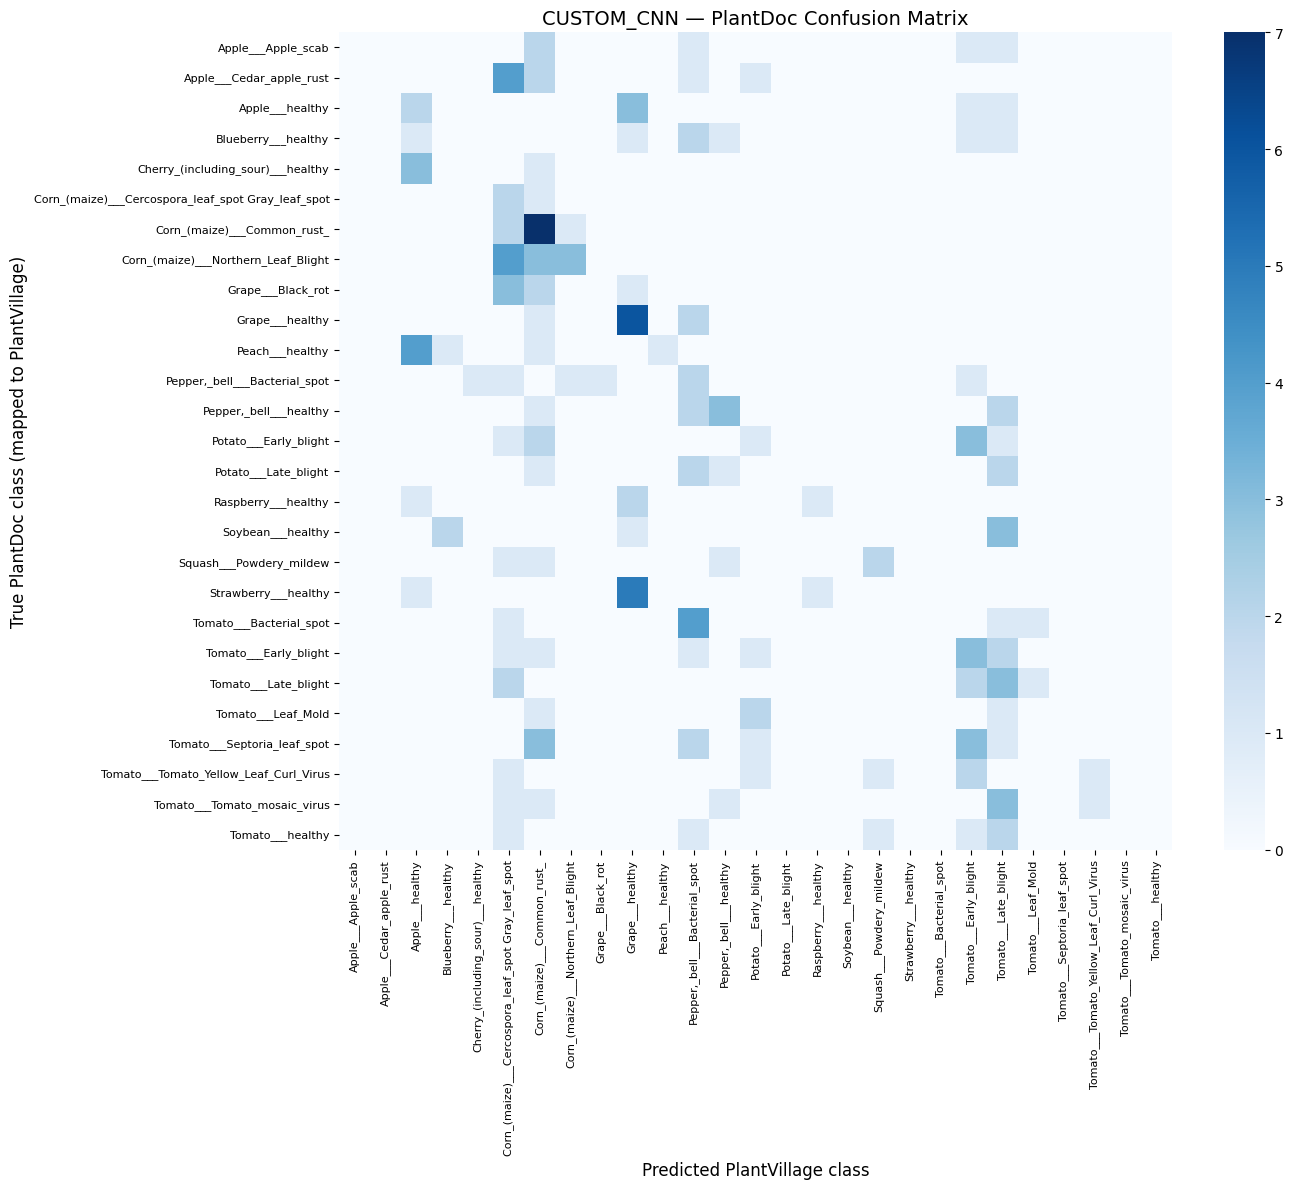

✅ Saved: /content/drive/MyDrive/PlantDiseaseProject/results/figures/custom_cnn_plantdoc_confusion_matrix.png



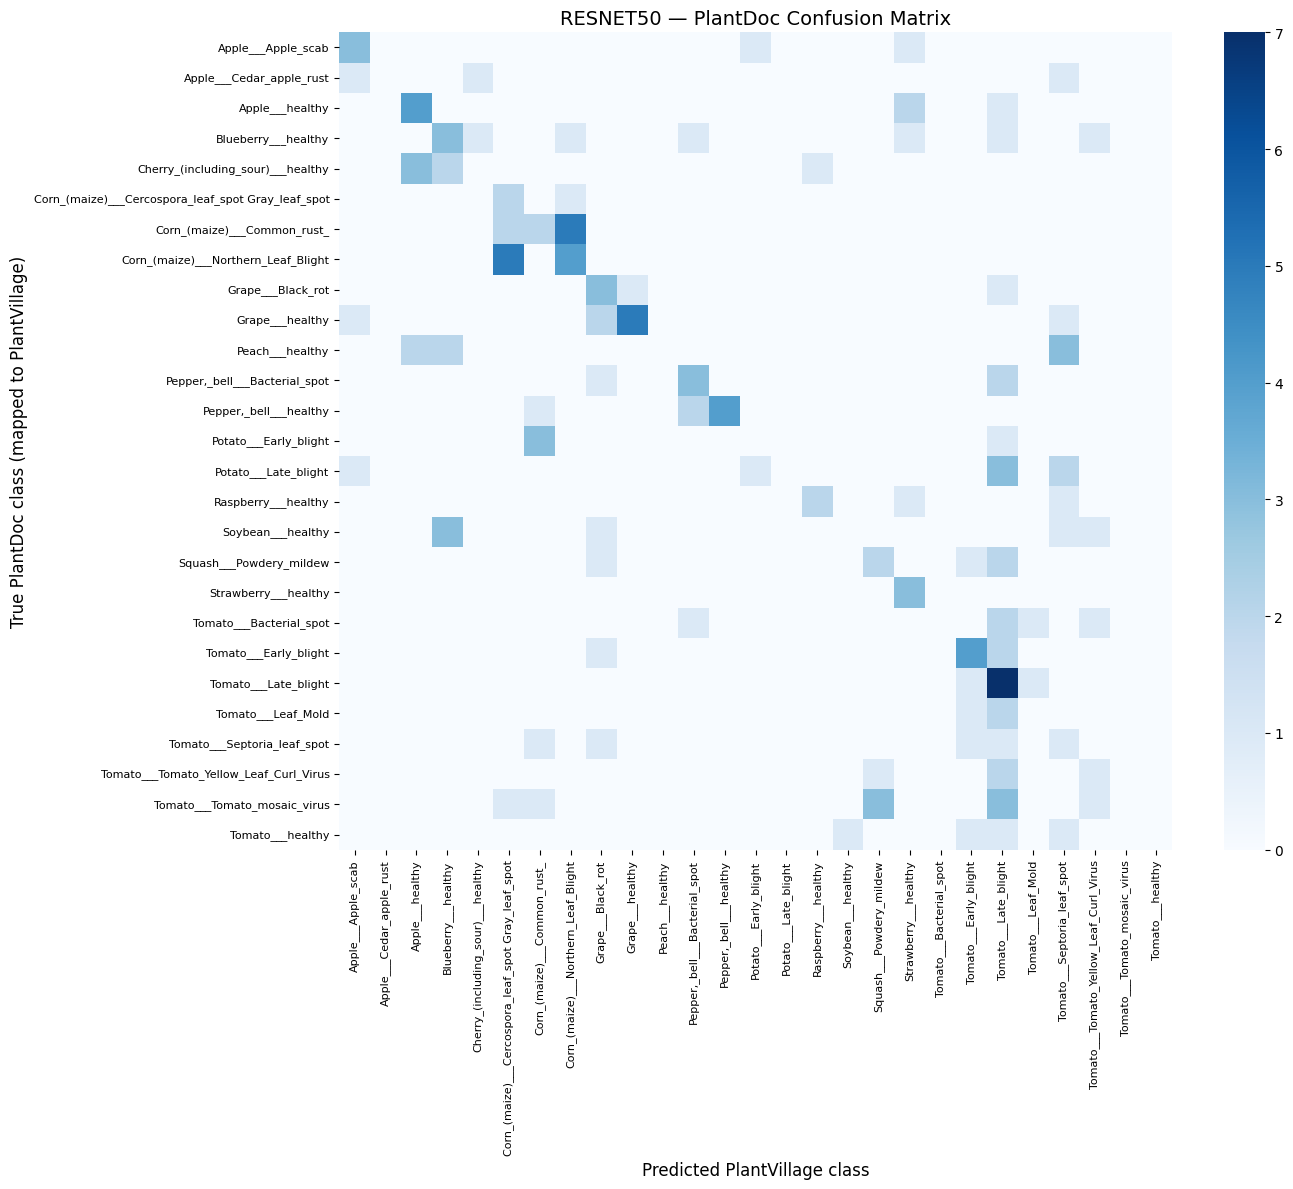

✅ Saved: /content/drive/MyDrive/PlantDiseaseProject/results/figures/resnet50_plantdoc_confusion_matrix.png



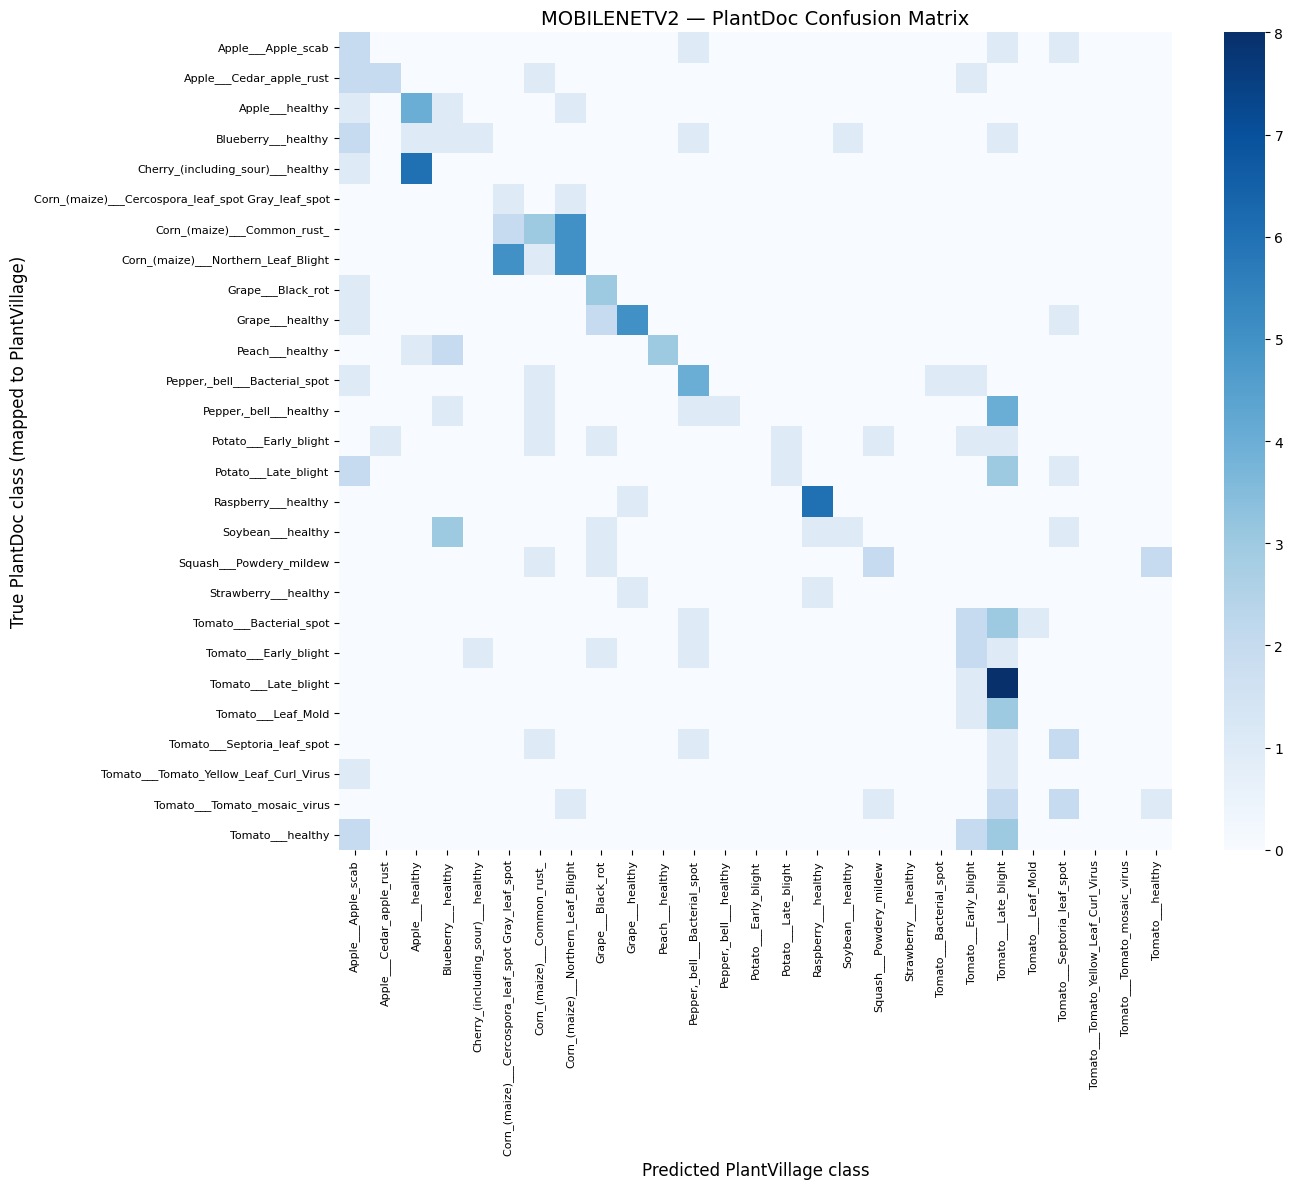

✅ Saved: /content/drive/MyDrive/PlantDiseaseProject/results/figures/mobilenetv2_plantdoc_confusion_matrix.png



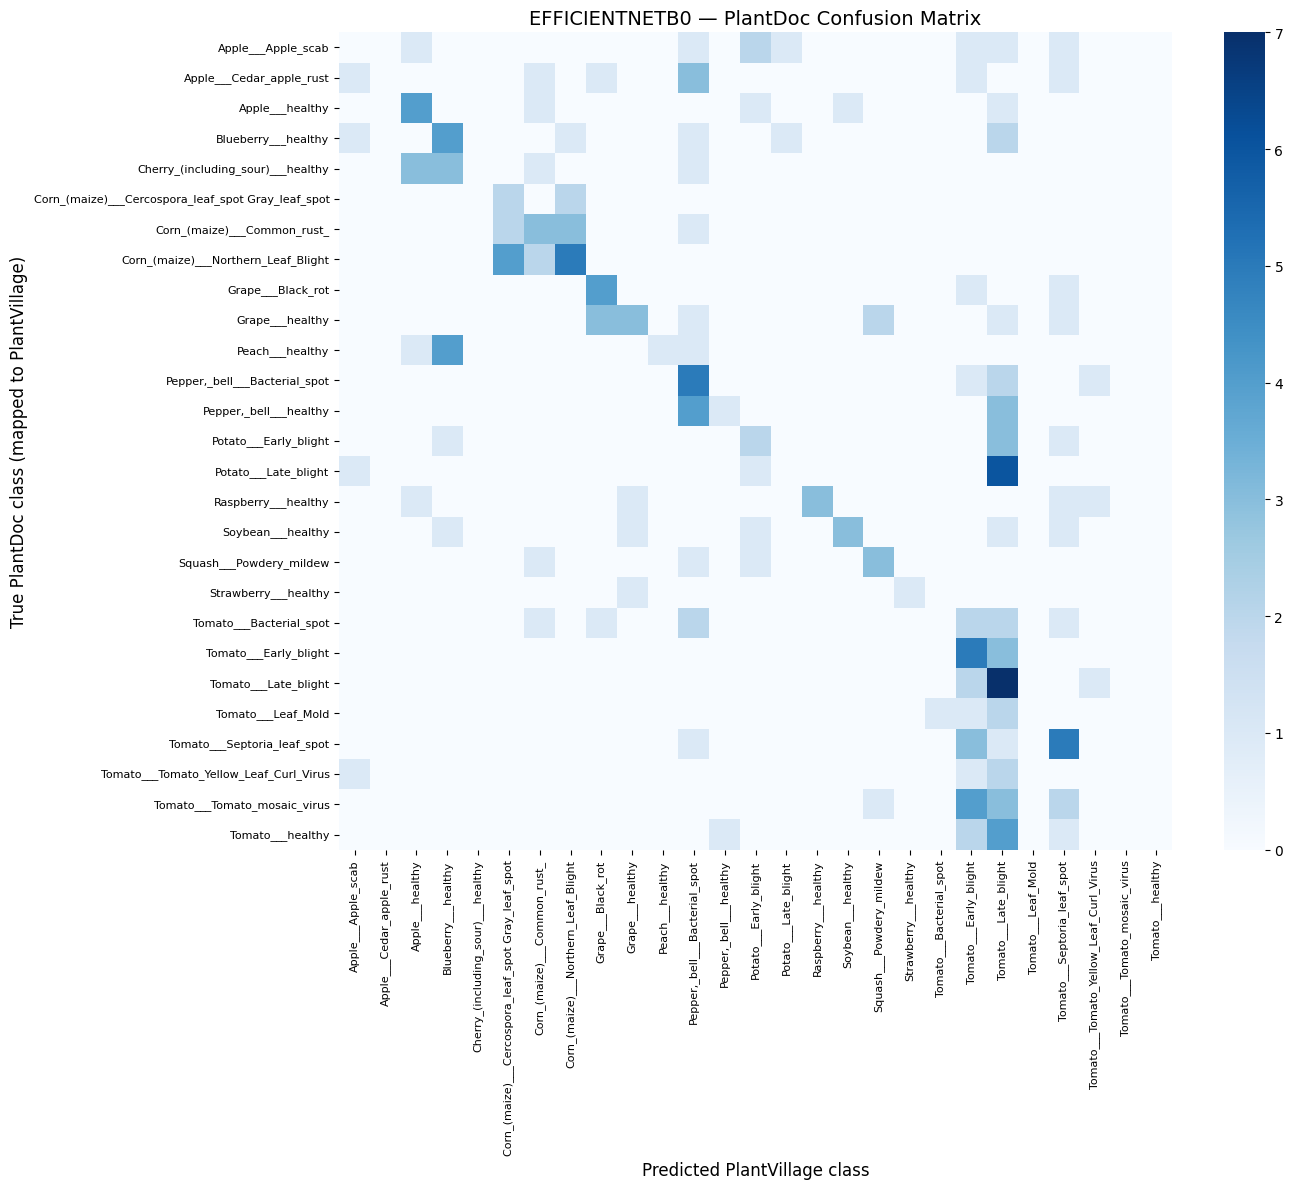

✅ Saved: /content/drive/MyDrive/PlantDiseaseProject/results/figures/efficientnetb0_plantdoc_confusion_matrix.png

Done.


In [15]:
import os, json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import pandas as pd

PROJECT_DIR = '/content/drive/MyDrive/PlantDiseaseProject'
METRICS_DIR = os.path.join(PROJECT_DIR, 'results', 'metrics')
FIG_DIR     = os.path.join(PROJECT_DIR, 'results', 'figures')
SPLIT_DIR   = os.path.join(PROJECT_DIR, 'results', 'splits')
os.makedirs(FIG_DIR, exist_ok=True)

# Load class names
class_df = pd.read_csv(os.path.join(SPLIT_DIR, 'class_names.csv'))
class_names = class_df['class'].tolist()

# Load predictions
preds = np.load(os.path.join(METRICS_DIR, 'plantdoc_predictions.npz'))
y_true = preds['y_true']

for model_name in ['custom_cnn', 'resnet50', 'mobilenetv2', 'efficientnetb0']:
    if model_name not in preds.files:
        print(f"⚠️ {model_name}: no predictions found")
        continue

    y_pred = preds[model_name]
    cm = confusion_matrix(y_true, y_pred, labels=range(len(class_names)))

    # Only show classes that actually appear in PlantDoc (true labels present)
    present = np.where(cm.sum(axis=1) > 0)[0]
    cm_sub = cm[np.ix_(present, present)]
    labels_sub = [class_names[i] for i in present]

    fig, ax = plt.subplots(figsize=(14, 12))
    sns.heatmap(cm_sub, annot=False, cmap='Blues', cbar=True, ax=ax,
                xticklabels=labels_sub, yticklabels=labels_sub)
    ax.set_xlabel('Predicted PlantVillage class', fontsize=12)
    ax.set_ylabel('True PlantDoc class (mapped to PlantVillage)', fontsize=12)
    ax.set_title(f'{model_name.upper()} — PlantDoc Confusion Matrix', fontsize=14)
    plt.xticks(rotation=90, fontsize=8)
    plt.yticks(rotation=0, fontsize=8)
    plt.tight_layout()

    save_path = os.path.join(FIG_DIR, f'{model_name}_plantdoc_confusion_matrix.png')
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ Saved: {save_path}\n")

print("Done.")

✅ Saved: /content/drive/MyDrive/PlantDiseaseProject/results/plantdoc_per_class_accuracy.csv

                                                    custom_cnn  resnet50  mobilenetv2  efficientnetb0  n_images
Grape___healthy                                       0.500000  0.416667     0.416667        0.250000        12
Corn_(maize)___Northern_Leaf_Blight                   0.250000  0.333333     0.416667        0.416667        12
Blueberry___healthy                                   0.000000  0.272727     0.090909        0.363636        11
Tomato___Septoria_leaf_spot                           0.000000  0.090909     0.181818        0.454545        11
Corn_(maize)___Common_rust_                           0.700000  0.200000     0.300000        0.300000        10
Apple___Apple_scab                                    0.000000  0.300000     0.200000        0.000000        10
Apple___Cedar_apple_rust                              0.000000  0.000000     0.200000        0.000000        10
Tomato___La

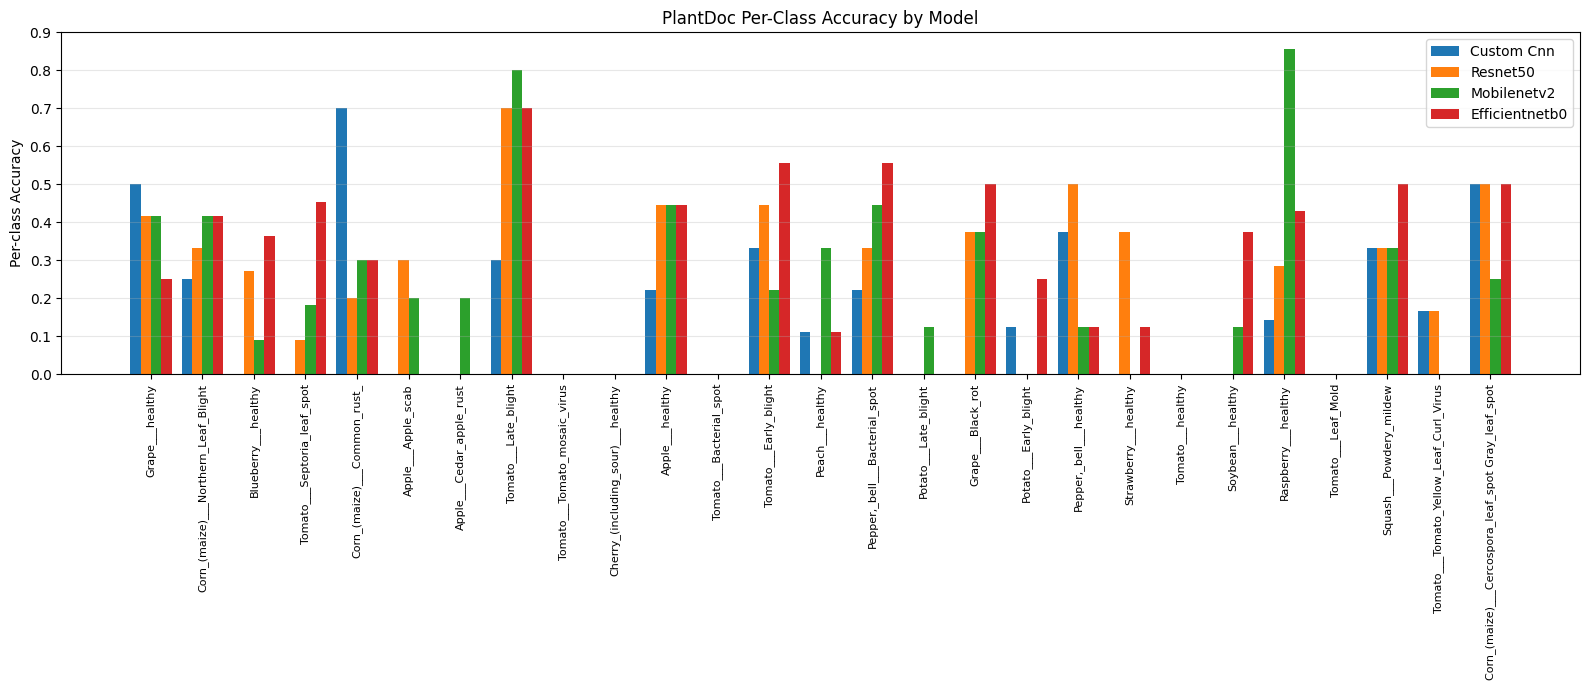

In [16]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_DIR = '/content/drive/MyDrive/PlantDiseaseProject'
METRICS_DIR = os.path.join(PROJECT_DIR, 'results', 'metrics')
FIG_DIR     = os.path.join(PROJECT_DIR, 'results', 'figures')
SPLIT_DIR   = os.path.join(PROJECT_DIR, 'results', 'splits')

class_df = pd.read_csv(os.path.join(SPLIT_DIR, 'class_names.csv'))
class_names = class_df['class'].tolist()

preds = np.load(os.path.join(METRICS_DIR, 'plantdoc_predictions.npz'))
y_true = preds['y_true']

models = ['custom_cnn', 'resnet50', 'mobilenetv2', 'efficientnetb0']
present = np.unique(y_true)

per_class = {}
for m in models:
    if m not in preds.files:
        continue
    y_pred = preds[m]
    accs = []
    for c in present:
        mask = y_true == c
        accs.append((y_pred[mask] == c).mean() if mask.sum() > 0 else np.nan)
    per_class[m] = accs

df_pc = pd.DataFrame(per_class, index=[class_names[i] for i in present])
df_pc['n_images'] = [int((y_true == c).sum()) for c in present]
df_pc = df_pc.sort_values('n_images', ascending=False)

csv_path = os.path.join(PROJECT_DIR, 'results', 'plantdoc_per_class_accuracy.csv')
df_pc.to_csv(csv_path)
print(f"✅ Saved: {csv_path}\n")
print(df_pc.to_string())

fig, ax = plt.subplots(figsize=(16, 7))
x = np.arange(len(df_pc))
width = 0.2
for i, m in enumerate(models):
    if m not in per_class:
        continue
    ax.bar(x + i*width, df_pc[m].values, width, label=m.replace('_',' ').title())
ax.set_xticks(x + 1.5*width)
ax.set_xticklabels(df_pc.index, rotation=90, fontsize=8)
ax.set_ylabel('Per-class Accuracy')
ax.set_title('PlantDoc Per-Class Accuracy by Model')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'plantdoc_per_class_accuracy.png'), dpi=150, bbox_inches='tight')
plt.show()